# 实盘峰值探测器

### get DATA

In [21]:
import pandas as pd
import numpy as np
import talib.abstract as ta

import ccxt

exchange = ccxt.binanceusdm({
	'apiKey': '',
	'secret': '',
})
# turn on dfnet
# hasattr(exchange, 'set_sandbox_mode')
exchange.set_sandbox_mode(True)

df = pd.DataFrame(exchange.fetch_ohlcv(symbol='ETHUSDT', timeframe='1h', limit= 1000))
df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
df.Date= pd.to_datetime(df.Date, unit='ms')
# 定义价格异常的条件，例如价格为负数或超出合理范围
price_columns = ['Open', 'High', 'Low', 'Close']
for col in price_columns:
    df[col] = df[col].mask((df[col] <= 0) | (df[col] > df[col].quantile(0.999)), np.nan)
    df[col] = df[col].ffill()

### test

In [8]:
test_s= pd.Series([1,2,3,4,5,4,3,2,1,0,1,2,3,4,5,6,5,4,3,2,1])
eq4 = test_s.where(test_s == 4).ffill()
diff = eq4 - test_s
diff

0     NaN
1     NaN
2     NaN
3     0.0
4    -1.0
5     0.0
6     1.0
7     2.0
8     3.0
9     4.0
10    3.0
11    2.0
12    1.0
13    0.0
14   -1.0
15   -2.0
16   -1.0
17    0.0
18    1.0
19    2.0
20    3.0
dtype: float64

### origin

In [ ]:
def generate_robust_reversal_signals(df, prominence_threshold=1.5):
    """
    Generates robust reversal signals using a real-time prominence logic.
    """

    rsi = ta.rsi(df, timeperiod=14)
    
    # 记录每个时间点的峰值和谷值: -> []
    high_p = rsi.where((rsi.shift(1) < rsi) & (rsi.shift(-1) < rsi)).ffill()
    low_v = rsi.where((rsi.shift(1) > rsi) & (rsi.shift(-1) > rsi)).ffill()
    
    # 计算从最近峰/谷的回落/反弹幅度 : -> [NaN, NaN, ... , val, val, ...]
    p_down = high_p - rsi
    v_rise = rsi - low_v
    
    # 寻找首次突破阈值的点
    sell_signal = (p_down > prominence_threshold) & (p_down.shift(1) <= prominence_threshold)
    buy_signal = (v_rise > prominence_threshold) & (v_rise.shift(1) <= prominence_threshold)

    signals = pd.Series(0, index=df.index)
    signals[buy_signal] = 1
    signals[sell_signal] = -1
    
    return signals

# --- 生成信号并查看 ---
df['simple_signal'] = generate_reversal_signals(df) # 旧方法，为了对比
df['robust_signal'] = generate_robust_reversal_signals(df, prominence_threshold=2.0)

# 打印有robust_signal的地方
print("Robust signals (filtered by prominence):")
print(df[df['robust_signal'] != 0])

### robust

In [17]:
import pandas as pd
import numpy as np

# --- 假设 df 和 exhaustion_score 已经存在 ---
def calculate_exhaustion_score(price_series, accel_smooth=5, vol_window=21, score_window=10):
    log_return = np.log(price_series / price_series.shift(1))
    raw_acceleration = log_return.diff()
    smoothed_acceleration = raw_acceleration.ewm(span=accel_smooth, adjust=False).mean()
    return_volatility = log_return.rolling(window=vol_window).std()
    epsilon = 1e-9
    normalized_acceleration = smoothed_acceleration / (return_volatility + epsilon)
    exhaustion_score = normalized_acceleration.rolling(window=score_window).sum()
    return exhaustion_score

np.random.seed(101)
prices = 100 * (1 + np.random.randn(500) / 75).cumsum()
df = pd.DataFrame(prices, columns=['price'])
df['exhaustion_score'] = calculate_exhaustion_score(df['price'])


def generate_robust_reversal_signals_final(df, prominence_threshold=1.5):
    """
    Generates robust reversal signals using a causal, real-time prominence logic.
    This is the final, production-ready version.
    """
    score = df['exhaustion_score']

    # --- 疑问一的最终解决方案 ---
    # 1. 在t时刻，判断t-1是否为峰/谷
    is_peak_at_t_minus_1 = (score.shift(1) > score.shift(2)) & (score.shift(1) > score)
    is_trough_at_t_minus_1 = (score.shift(1) < score.shift(2)) & (score.shift(1) < score)

    # 2. 提取t-1时刻的峰/谷值
    peak_values = score.shift(1).where(is_peak_at_t_minus_1)
    trough_values = score.shift(1).where(is_trough_at_t_minus_1)

    # 3. 获得历史上最近的峰/谷值
    last_peak = peak_values.ffill()
    last_trough = trough_values.ffill()

    # --- 疑问二的最终解决方案 ---
    # 4. 计算从最近峰/谷的回落/反弹幅度
    p_down = last_peak - score
    v_rise = score - last_trough
    
    # 5. 寻找首次突破阈值的点 (逻辑被证明是稳健的)
    sell_signal = (p_down > prominence_threshold) & (p_down.shift(1) <= prominence_threshold)
    buy_signal = (v_rise > prominence_threshold) & (v_rise.shift(1) <= prominence_threshold)

    signals = pd.Series(0, index=df.index)
    signals[buy_signal] = 1
    signals[sell_signal] = -1
    
    return signals

### 在代码中实现“时间过滤器”

In [3]:
# test
is_p8tminus1 = pd.Series([False, False, True, False, False, False, False])
is_v8tminus1 = pd.Series([False, False, False, False, True, False, False])

is_new_cycle_start = is_p8tminus1 | is_v8tminus1
is_new_cycle_start

0    False
1    False
2     True
3    False
4     True
5    False
6    False
dtype: bool

In [4]:
cycle_id= is_new_cycle_start.cumsum()
cycle_id

0    0
1    0
2    1
3    1
4    2
5    2
6    2
dtype: int32

In [5]:
# 3. 创建周期ID，并在每个周期内计数 (核心步骤)
duration_in_cycle = cycle_id.groupby(cycle_id).cumcount()
duration_in_cycle

0    0
1    1
2    0
3    1
4    0
5    1
6    2
dtype: int64

### use

In [ ]:
def rolling_percentile(arr) -> float:
    ranks = np.argsort(np.argsort(arr))
    return ranks[-1] / (len(arr) - 1) * 100

def BIAS_percentile(dataframe:pd.DataFrame, baseline_period= 144, percentile_window= 377):
    dataframe['tp'] = (dataframe['High'] + dataframe['Low'] + dataframe['Close']) / 3
    dataframe['MA_144'] = ta.MA(dataframe['tp'], timeperiod=baseline_period)
    bias = (dataframe['tp'] - dataframe['MA_144']) / dataframe['MA_144'] * 100

    percentile_rank = bias.rolling(window= 377).apply(rolling_percentile, raw=True)
    return percentile_rank

def generate_filtered_reversal_signals(
    dataframe:pd.DataFrame, 
    prominence_threshold=0.4, 
    v_window= 126, 
    std_multiplier= 2, 
    max_duration_bars=3,
    percentile_window= 377
    ):
    """
    Generates reversal signals filtered by both prominence and duration.
    This is the most advanced version.
    """
    score = dataframe['score'].copy()
    # 1. 识别t-1时刻的峰/谷 (无未来函数)
    is_peak_at_t_minus_1 = (score.shift(1) > score.shift(2)) & (score.shift(1) > score)
    is_trough_at_t_minus_1 = (score.shift(1) < score.shift(2)) & (score.shift(1) < score)
    
    # 2. 识别新周期的开始
    is_new_cycle_start = is_peak_at_t_minus_1 | is_trough_at_t_minus_1

    # 3. 创建周期ID，并在每个周期内计数 (核心步骤)
    cycle_id = is_new_cycle_start.cumsum()
    duration_in_cycle = cycle_id.groupby(cycle_id).cumcount()

    # 4. 获取最近的峰/谷值
    peak_values = score.shift(1).where(is_peak_at_t_minus_1)
    trough_values = score.shift(1).where(is_trough_at_t_minus_1)
    last_peak = peak_values.ffill()
    last_trough = trough_values.ffill()

    # 5. 计算回落/反弹幅度
    p_down = last_peak - score
    v_rise = score - last_trough
    
    # 6. 寻找首次突破阈值的点
    dynamic_prominence_threshold = score.rolling(window=v_window).std() * std_multiplier     # TODO: dynamic thresholding?
    threshold = dynamic_prominence_threshold
    sell_trigger = (p_down > threshold) & (p_down.shift(1) <= threshold)
    buy_trigger = (v_rise > threshold) & (v_rise.shift(1) <= threshold)

    # 7. 应用 duration filter and RANGE filter
    s_p_rank = score.rolling(window= 126).apply(rolling_percentile, raw=True)
    percentile_rank = BIAS_percentile(dataframe, baseline_period=144, percentile_window=percentile_window)
    sell_signal =  (percentile_rank.shift(1) > 70) & (s_p_rank.shift(1) > 80) & sell_trigger & (duration_in_cycle <= max_duration_bars)
    buy_signal = (percentile_rank.shift(1) < 30) & (s_p_rank < 20) & buy_trigger & (duration_in_cycle <= max_duration_bars)

    signals = pd.Series(0, index=score.index)
    signals[buy_signal] = 1
    signals[sell_signal] = -1
    # pd.toDaframe({'signals': signals, 'duration': duration_in_cycle})
    
    # return signals, duration_in_cycle # 返回duration方便调试
    return pd.DataFrame({'signals': signals, 'duration': duration_in_cycle, 'percentile_rank': percentile_rank})

### test

In [81]:
def calculate_exhaustion_score_robust(price_series, accel_smooth=5, vol_window=21, score_window=8, long_vol_window= 252):
    """
    Calculates a professional-grade and numerically stable Trend Exhaustion Score.

    Args:
        price_series (pd.Series): The series of asset prices.
        accel_smooth (int): Smoothing period for the acceleration signal (EMA span).
        vol_window (int): Lookback window for volatility normalization (rolling std).
        score_window (int): Lookback window for accumulating the score (rolling sum).
        long_vol_window (int): A longer window to establish a baseline volatility for the floor.

    Returns:
        pd.Series: The final, stable Trend Exhaustion Score.
    """
    log_return = np.log(price_series / price_series.shift(1))
    raw_acceleration = log_return.diff()
    smoothed_acceleration = raw_acceleration.ewm(span=accel_smooth, adjust=False).mean()
    # --- 【核心修正】 ---
    # 1. 计算短期的、可能不稳定的波动率
    return_volatility = log_return.rolling(window=vol_window).std()
    # 2. 计算一个长期的、更稳定的基准波动率，并以此设定一个动态的“地板”
    #    我们取长期波动率均值的10%作为下限，这是一个合理的起点
    volatility_floor = return_volatility.rolling(window=long_vol_window).mean().mean() * 0.1
    epsilon = 1e-9 # 仍然保留epsilon以防万一
    # 3. 使用 .clip() 方法，确保波动率不会低于我们设定的地板值 + epsilon
    stable_volatility = return_volatility.clip(lower=volatility_floor) + epsilon
    # 4. 使用稳定后的波动率进行标准化
    normalized_acceleration = smoothed_acceleration / stable_volatility
    # --- 【修正结束】 ---
    # (可选) 为了进一步增强稳健性，可以对标准化后的结果也进行clip，防止极端情况
    normalized_acceleration = normalized_acceleration.clip(-10, 10)
    exhaustion_score = normalized_acceleration.rolling(window=score_window).sum()
    return exhaustion_score

In [82]:
df['score'] = calculate_exhaustion_score_robust(df['Close']) 

In [83]:
df

,Date,Open,High,Low,Close,Volume,score,signals,duration,MA144,percentile_rank,tp,MA_144
0,2025-09-08 17:00:00,4309.84,4433.26,4270.00,4309.50,1083.133,NaN,0,0,NaN,NaN,4337.586667,NaN
1,2025-09-08 18:00:00,4309.26,4430.00,4270.00,4369.67,1027.664,NaN,0,1,NaN,NaN,4356.556667,NaN
2,2025-09-08 19:00:00,4375.88,4420.00,4100.00,4290.33,12559.238,NaN,0,2,NaN,NaN,4270.110000,NaN
3,2025-09-08 20:00:00,4291.48,4360.00,4099.69,4288.47,3606.140,NaN,0,3,NaN,NaN,4249.386667,NaN
4,2025-09-08 21:00:00,4288.47,4312.50,4210.00,4312.34,25992.622,NaN,0,4,NaN,NaN,4278.280000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2025-10-20 04:00:00,4100.99,4190.00,4035.00,4048.71,3706.865,0.230079,0,3,3955.484028,82.446809,4091.236667,3963.911968
996,2025-10-20 05:00:00,4184.00,4190.00,4044.00,4152.90,2952.647,1.098232,0,4,3956.075764,91.223404,4128.966667,3964.235602
997,2025-10-20 06:00:00,4152.90,4173.00,4071.40,4073.06,107693.077,0.235154,0,0,3956.561806,85.904255,4105.820000,3964.828333
998,2025-10-20 07:00:00,4073.06,4073.73,4052.01,4053.17,111322.546,0.042421,0,1,3957.070764,75.797872,4059.636667,3965.298727


In [84]:
df[['signals', 'duration', 'percentile_rank']] = generate_filtered_reversal_signals(df, prominence_threshold=0.5, std_multiplier=2, max_duration_bars=4)

In [85]:
df.tail(100)

,Date,Open,High,Low,Close,Volume,score,signals,duration,MA144,percentile_rank,tp,MA_144
900,2025-10-16 05:00:00,3996.86,4018.49,3981.36,3994.88,502263.741,0.351434,0,5,4022.308125,41.223404,3998.243333,4022.348356
901,2025-10-16 06:00:00,3994.87,4044.00,3994.03,4040.65,313546.377,0.798512,0,0,4020.327569,47.340426,4026.226667,4020.166782
902,2025-10-16 07:00:00,4041.00,4042.96,3994.45,4000.00,270044.837,-0.358130,0,0,4018.098056,46.276596,4012.470000,4018.015926
903,2025-10-16 08:00:00,3998.64,4004.40,3982.81,3992.78,203239.569,-0.274129,0,0,4015.659583,42.021277,3993.330000,4015.643125
904,2025-10-16 09:00:00,3992.78,4039.90,3944.67,4028.56,829386.245,-0.095021,0,1,4013.633403,46.010638,4004.376667,4013.391481
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2025-10-20 04:00:00,4100.99,4190.00,4035.00,4048.71,3706.865,0.230079,0,3,3955.484028,82.446809,4091.236667,3963.911968
996,2025-10-20 05:00:00,4184.00,4190.00,4044.00,4152.90,2952.647,1.098232,0,4,3956.075764,91.223404,4128.966667,3964.235602
997,2025-10-20 06:00:00,4152.90,4173.00,4071.40,4073.06,107693.077,0.235154,0,0,3956.561806,85.904255,4105.820000,3964.828333
998,2025-10-20 07:00:00,4073.06,4073.73,4052.01,4053.17,111322.546,0.042421,0,1,3957.070764,75.797872,4059.636667,3965.298727


In [86]:
signal = df['signals'].copy()
signal.where(signal == 1).count()

0

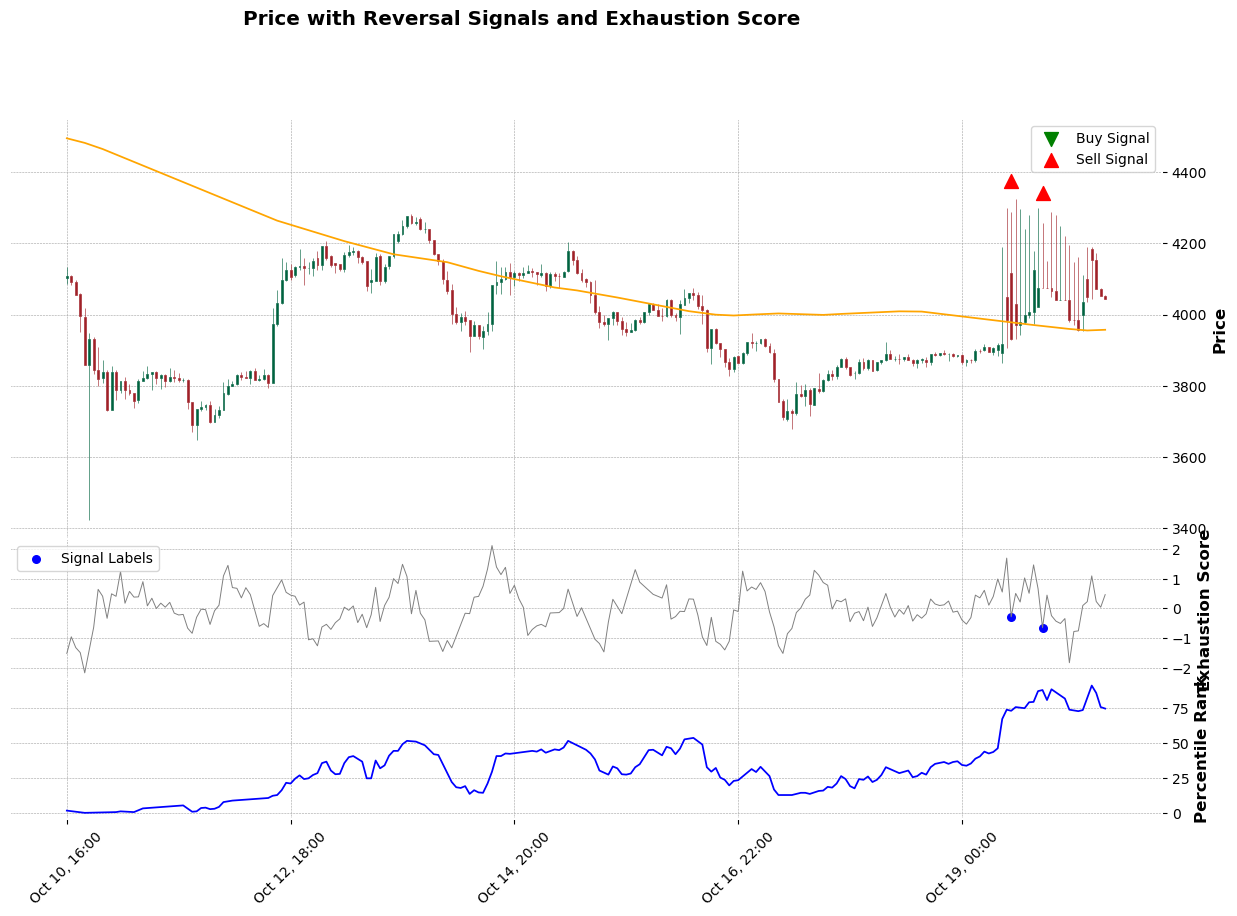

In [87]:
# visualization of signals
# use mpf to visualize the signals by labels on the subplot
# locate the signals
# pdf = df.set_index('Date')[['Open', 'High', 'Low', 'Close', 'exhaustion_score', 'signals']].tail(500).copy()
import mplfinance as mpf

df['MA144'] = ta.MA(df['Close'], timeperiod=144)
pdf = df.set_index('Date')[['Open', 'High', 'Low', 'Close', 'MA144', 'score', 'duration', 'percentile_rank', 'signals']].tail(233).copy()

bull = np.where(
    pdf['signals'] == 1,
    pdf['Low'] * 0.98,
    np.nan
)
bear = np.where(
    pdf['signals'] == -1,
    pdf['High'] * 1.02,
    np.nan
)
subplot_labels = np.where(
    (pdf['signals'] != 0),
    pdf['score'],
    np.nan
)

# plotting
ap = [
    # subplot for exhaustion_score
    mpf.make_addplot(pdf['score'], panel=1, color='gray', width= 0.7, ylabel='Exhaustion Score'),
    # add MA144
    mpf.make_addplot(pdf['MA144'], color='orange', ylabel='MA144', secondary_y=False),
    # subplot for signals
    mpf.make_addplot(subplot_labels, type='scatter', markersize=30, marker='o', color='blue', panel=1, secondary_y=False, label='Signal Labels'),
    # main chart for buy/sell signals
    mpf.make_addplot(bull, type='scatter', markersize=100, marker='v', color='green', panel=0, secondary_y=False, label='Buy Signal'),
    mpf.make_addplot(bear, type='scatter', markersize=100, marker='^', color='red', panel=0, secondary_y=False, label='Sell Signal'),
    # add BIAS_percentile 
    # mpf.make_addplot(pdf['BIAS_percentile'], panel=2, color='blue', ylabel='tp_BIAS', secondary_y=False)
    # add subplot for duration as bar chart
    # mpf.make_addplot(pdf['duration'], type='bar', panel=2, color='orange', ylabel='Duration', secondary_y=False)
    # add subplot for percentile_rank as line chart
    mpf.make_addplot(pdf['percentile_rank'], panel=2, color='blue', ylabel='Percentile Rank', secondary_y=False)
]

mpf.plot(
    pdf,
    type='candle',
    style='charles',
    addplot=ap,
    figsize=(16, 10),
    title="Price with Reversal Signals and Exhaustion Score",
    panel_ratios=(3, 1, 1),
    # datetime_format='%Y-%m-%d %H:%M:%S'
)